# Model Evaluation

This notebook evaluates the selected Random Forest model using:

1. Feature Importance Analysis
2. 5-Fold Cross Validation

The final trained model is then saved to disk for future inference.

In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Random forest model(selected model)


In [8]:
# loading dataset
X_features=np.load(r"C:\Users\suhan\OneDrive\Desktop\channel noise estimator\data\X_features.npy")
print("feature matrix shape: ", X_features.shape)
y=np.load(r"C:\Users\suhan\OneDrive\Desktop\channel noise estimator\data\y_snr.npy")
print("label shape: ", y.shape)
#train test split
X_train, X_test, y_train, y_test= train_test_split(X_features,y,test_size=0.2,random_state=42)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
#Random Forest regressor
rf=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train_scaled,y_train)

feature matrix shape:  (21000, 7)
label shape:  (21000,)
Training Samples: 16800
Testing Samples: 4200


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [9]:
feature_names=["variance","Kurtosis","Skewness","Zero Crossing rate","Spectral Entropy","FFT peak ratio","mean absolute value"]
importance=rf.feature_importances_
for name,score in zip(feature_names,importance):
    print(f"{name:20s}:{score:.4f}")
    

variance            :0.1668
Kurtosis            :0.7930
Skewness            :0.0008
Zero Crossing rate  :0.0008
Spectral Entropy    :0.0155
FFT peak ratio      :0.0029
mean absolute value :0.0202


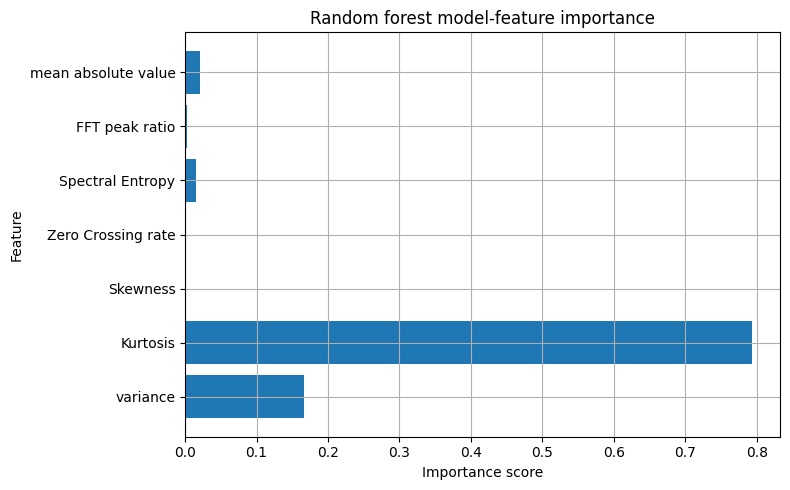

In [10]:
plt.figure(figsize=(8,5))
plt.barh(feature_names,importance)
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.title("Random forest model-feature importance")
plt.grid(True)
plt.tight_layout()
plt.savefig("Feature importance.png")
plt.show()

## Interpretation
Feature importance analysis shows that signal characteristics Kurtosis and variance are most influential in predicting channel SNR

# 5-Fold Cross validation
Cross-validation evaulates model performance across multiple train-validation splits.
This helps in generalization of performance over a single train-test-split

In [11]:
cv_scores=cross_val_score(rf,X_train_scaled,y_train,cv=5,scoring="neg_mean_absolute_error",n_jobs=-1)
cv_mae= -cv_scores
print("fold MAEs: ")
for i,score in enumerate(cv_mae,start=1):
     print(f"Fold {i}: {score:.4f}")
print(f"\nMean MAE: {cv_mae.mean():.4f}")
print(f"Std MAE: {cv_mae.std():.4f}")

fold MAEs: 
Fold 1: 0.5712
Fold 2: 0.5702
Fold 3: 0.5827
Fold 4: 0.5916
Fold 5: 0.5967

Mean MAE: 0.5825
Std MAE: 0.0106


### Cross-Validation Results

A 5-fold cross-validation experiment was performed on the selected Random Forest model.

The model achieved a mean MAE of 0.5825 dB with a standard deviation of 0.0106 dB across the five folds. The low standard deviation indicates highly consistent performance across different train-validation splits, suggesting that the model generalizes reliably and is not strongly dependent on a particular partition of the dataset.

These results confirm that the strong performance observed on the test set is representative of the model's expected behavior on unseen data.

In [13]:
os.makedirs("../models",exist_ok=True)
with open("../models/rf_snr_estimator.pkl","wb") as file:
    pickle.dump(rf,file)


print("Model and scaler saved.")

Model and scaler saved.


verification:

In [14]:
with open("../models/rf_snr_estimator.pkl","rb") as file:
    loaded_model = pickle.load(file)
print(type(loaded_model))


<class 'sklearn.ensemble._forest.RandomForestRegressor'>


# Conclusions

Feature importance analysis identified the most influential statistical and spectral features used by the Random Forest model for SNR estimation.

5-fold cross-validation confirmed that the model generalizes consistently across different data splits and provides stable prediction performance.

The final trained Random Forest model was successfully saved and is ready for deployment and inference on unseen communication signals.

In [15]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [19]:
import pickle
with open(
    "../models/scaler.pkl",
    "wb"
) as f:
    pickle.dump(scaler, f)